In [153]:
#plot colors: data: royalblue, fit: firebrick, fit interval: green, result error interval: purple


import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit



def numeric_suffix_key(filename):
    stem = os.path.splitext(filename)[0]
    suffix = stem.rsplit("_", 1)[-1]
    return int(suffix) if suffix.isdigit() else float("inf")

def cauchy_offset(x, A, gamma, k):
        return A/(np.pi*gamma*(1 + ((x)/gamma)**2)) + k

def linfunc(x, a, b):
    return a*x + b

data_dir = "../output/FINAL/FerroTrekant" # HUSK AT ÆNDRE DEN HER TIL DEN RIGTIGE MAPPE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
#data_dir = "../output/FINAL/WolffFerroFirkant" # HUSK AT ÆNDRE DEN HER TIL DEN RIGTIGE MAPPE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
#data_dir = "../output/FINAL/FirkantSingleFlip" # HUSK AT ÆNDRE DEN HER TIL DEN RIGTIGE MAPPE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

parameterFiles = np.array(sorted(os.listdir(data_dir + "/parameters"), key=numeric_suffix_key))
measurementFiles = np.array(sorted(os.listdir(data_dir + "/measurements"), key=numeric_suffix_key))
kvadratFFTFiles = np.array(sorted(os.listdir(data_dir + "/kvadratFFT"), key=numeric_suffix_key))
kvadratFFTVarFiles = np.array(sorted(os.listdir(data_dir + "/kvadratFFTvariance"), key=numeric_suffix_key))

print("Parameterfiler:", parameterFiles)
print("Måledatafiler:", measurementFiles)
print("Kvadrat FFT filer:", kvadratFFTFiles)
print("Kvadrat FFT varians filer:", kvadratFFTVarFiles)

størrelser = np.array([int(os.path.splitext(f)[0].split("_")[-1]) for f in parameterFiles])
parameter_data = np.genfromtxt(data_dir + "/parameters/" + parameterFiles[0], delimiter=",", skip_header=0)[:, :-1]
temperaturer = parameter_data[:, 1]

print("Størrelser:", størrelser)
print("Temperaturer:", temperaturer)

antalStørrelser = len(størrelser)
antalTemperaturer = len(temperaturer)


korrLen2D =np.zeros((antalStørrelser, antalTemperaturer))
korrLenUsik2D = np.zeros((antalStørrelser, antalTemperaturer))

magnetiseringer2D = np.zeros((antalStørrelser, antalTemperaturer))
magnetiseringerUsik2D = np.zeros((antalStørrelser, antalTemperaturer))

susceptibiliteter2D = np.zeros((antalStørrelser, antalTemperaturer))
susceptibiliteterUsik2D = np.zeros((antalStørrelser, antalTemperaturer))

energier2D = np.zeros((antalStørrelser, antalTemperaturer))
energierUsik2D = np.zeros((antalStørrelser, antalTemperaturer))

varmekapaciteter2D = np.zeros((antalStørrelser, antalTemperaturer))
varmekapaciteterUsik2D = np.zeros((antalStørrelser, antalTemperaturer))

print(antalTemperaturer)

# loop over hver enkelt simulation
for j in range(0,antalStørrelser):
    for i in range(0, antalTemperaturer):
        print(f"Processing size {størrelser[j]}, temperature {temperaturer[i]}...")

        parameters = np.genfromtxt(data_dir + "/parameters/" + parameterFiles[j], delimiter=",")[i,:-1]
        measurements = np.genfromtxt(data_dir + "/measurements/" + measurementFiles[j], delimiter=",")[i,:-1]
        kvadratFFT = np.genfromtxt(data_dir + "/kvadratFFT/" + kvadratFFTFiles[j], delimiter=",")[i,:-1]
        kvadratFFTVar = np.genfromtxt(data_dir + "/kvadratFFTvariance/" + kvadratFFTVarFiles[j], delimiter=",")[i,:-1]

        count = measurements[0]

        magnetiseringer2D[j, i] = measurements[1]
        magnetiseringerUsik2D[j, i] = np.sqrt(measurements[2] / count)  # Usikkerhed på magnetiseringen

        susceptibiliteter2D[j, i] = measurements[2] * størrelser[j]**2
        susceptibiliteterUsik2D[j, i] = np.sqrt(measurements[3] / count) * størrelser[j]**2  # Usikkerhed på susceptibiliteten

        energier2D[j, i] = measurements[4]
        energierUsik2D[j, i] = np.sqrt(measurements[5] / count)  # Usikkerhed på energien

        varmekapaciteter2D[j, i] = measurements[5] * størrelser[j]**2 / temperaturer[i]**2
        varmekapaciteterUsik2D[j, i] = np.sqrt(measurements[6] / count) * størrelser[j]**2 / temperaturer[i]**2  # Usikkerhed på varmekapaciteten



        # FFT shit
        kvadratFFT2D = np.fft.fftshift(np.split(kvadratFFT, størrelser[j]))
        kvadratFFT1D = kvadratFFT2D[int(størrelser[j]//2)]  # Tag den midterste række (k_y = 0)

        
        kvadratFFTVar2D = np.fft.fftshift(np.split(kvadratFFTVar, størrelser[j]))
        kvadratFFTVar1D = kvadratFFTVar2D[int(størrelser[j]//2)]  # Tag den midterste række (k_y = 0)


        kvadratFFT1Dusikkerhed = np.sqrt(kvadratFFTVar1D / count)  # Usikkerhed på gennemsnittet er standardafvigelsen delt med kvadratroden af antallet af målinger


        kvadratFFT1D = np.delete(kvadratFFT1D, størrelser[j]//2)  # Fjern det midterste element (k_y = 0)
        kvadratFFT1Dusikkerhed = np.delete(kvadratFFT1Dusikkerhed, størrelser[j]//2)  # Fjern usikkerheden for det midterste

        X = np.arange(-størrelser[j]//2, størrelser[j]//2)
        
        if (størrelser[j] % 2 == 1):
             X+=1
        
        X = X * 2 * np.pi / størrelser[j]  # Konverter til bølgetal
        X = np.delete(X, størrelser[j]//2)  # Fjern det midterste element (k_y = 0)



        p0 = [max(kvadratFFT1D), 0.1, min(kvadratFFT1D)]  # Initiale gæt for A, gamma og k
        par, cov = curve_fit(cauchy_offset, X, kvadratFFT1D, sigma=kvadratFFT1Dusikkerhed, p0=p0, maxfev=50000, bounds=([0, 0, -np.inf], [np.inf, np.inf, np.inf]))

        korrlen = 1 / par[1]  # Korrrelationslængde er inversen af gamma
        korrlen_usikkerhed = cov[1, 1]**0.5 / par[1]**2  # Usikkerhed på korrrelationslængden
        korrLen2D[j, i] = korrlen
        korrLenUsik2D[j, i] = korrlen_usikkerhed

        '''
        plt.errorbar(X, kvadratFFT1D, yerr=kvadratFFT1Dusikkerhed, fmt='o', label='Data')
        x_fit = np.linspace(X.min(), X.max(), 1000)
        y_fit = cauchy_offset(x_fit, *par)
        plt.plot(x_fit, y_fit, label='Fit', color='red')
        plt.xlabel('Bølgetal k')
        plt.ylabel('Kvadrat af Fourier-transformationen')
        plt.title(f'Kvadrat FFT for størrelse {størrelser[j]} ved temperatur {temperaturer[i]}')
        plt.legend()
        plt.show()
        '''



Parameterfiler: ['parameters_100.csv' 'parameters_105.csv' 'parameters_110.csv'
 'parameters_118.csv' 'parameters_125.csv' 'parameters_134.csv'
 'parameters_142.csv' 'parameters_154.csv' 'parameters_166.csv'
 'parameters_180.csv' 'parameters_200.csv']
Måledatafiler: ['measurements_100.csv' 'measurements_105.csv' 'measurements_110.csv'
 'measurements_118.csv' 'measurements_125.csv' 'measurements_134.csv'
 'measurements_142.csv' 'measurements_154.csv' 'measurements_166.csv'
 'measurements_180.csv' 'measurements_200.csv']
Kvadrat FFT filer: ['kvadratFFT_100.csv' 'kvadratFFT_105.csv' 'kvadratFFT_110.csv'
 'kvadratFFT_118.csv' 'kvadratFFT_125.csv' 'kvadratFFT_134.csv'
 'kvadratFFT_142.csv' 'kvadratFFT_154.csv' 'kvadratFFT_166.csv'
 'kvadratFFT_180.csv' 'kvadratFFT_200.csv']
Kvadrat FFT varians filer: ['kvadratFFTvariance_100.csv' 'kvadratFFTvariance_105.csv'
 'kvadratFFTvariance_110.csv' 'kvadratFFTvariance_118.csv'
 'kvadratFFTvariance_125.csv' 'kvadratFFTvariance_134.csv'
 'kvadratFFTvari

/tmp/ipykernel_3801141/4166017642.py:82: RuntimeWarning: invalid value encountered in sqrt
  susceptibiliteterUsik2D[j, i] = np.sqrt(measurements[3] / count) * størrelser[j]**2  # Usikkerhed på susceptibiliteten
/tmp/ipykernel_3801141/4166017642.py:88: RuntimeWarning: invalid value encountered in sqrt
  varmekapaciteterUsik2D[j, i] = np.sqrt(measurements[6] / count) * størrelser[j]**2 / temperaturer[i]**2  # Usikkerhed på varmekapaciteten


Processing size 100, temperature 2.5...
Processing size 100, temperature 3.0...
Processing size 100, temperature 3.2...
Processing size 100, temperature 3.3...
Processing size 100, temperature 3.4...
Processing size 100, temperature 3.4...
Processing size 100, temperature 3.55...
Processing size 100, temperature 3.6...
Processing size 100, temperature 3.62...
Processing size 100, temperature 3.64...
Processing size 100, temperature 3.66...
Processing size 100, temperature 3.67...
Processing size 100, temperature 3.69...
Processing size 100, temperature 3.72...
Processing size 100, temperature 3.75...
Processing size 100, temperature 3.8...
Processing size 100, temperature 3.95...
Processing size 100, temperature 4.5...
Processing size 100, temperature 6.5...
Processing size 105, temperature 1.0...
Processing size 105, temperature 2.5...
Processing size 105, temperature 3.0...
Processing size 105, temperature 3.2...
Processing size 105, temperature 3.3...
Processing size 105, temperatur

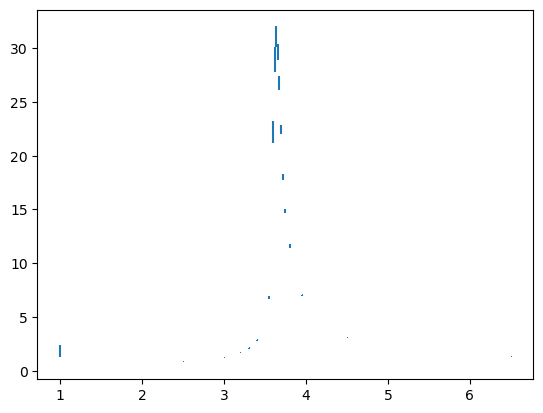

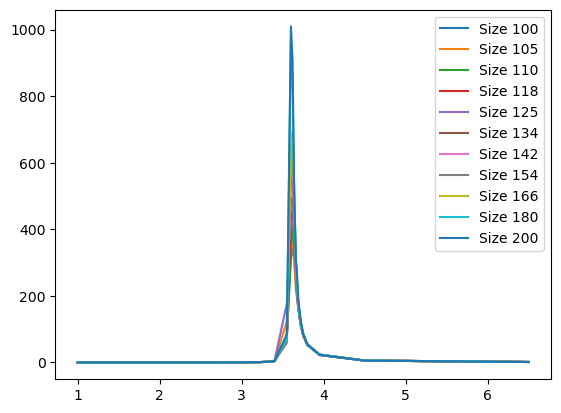

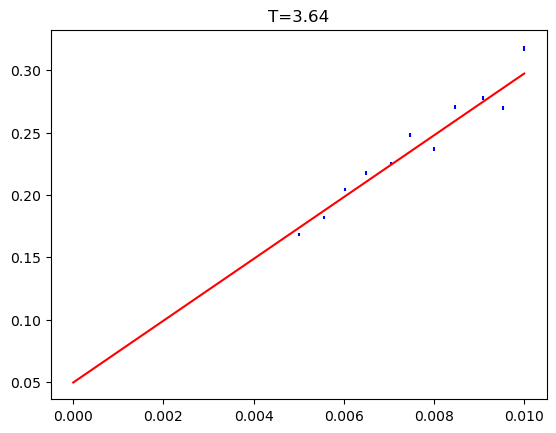

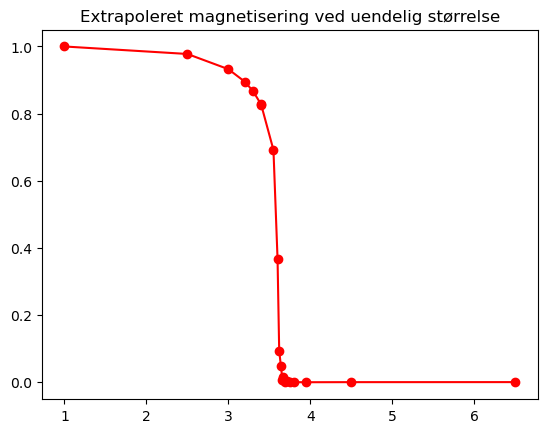

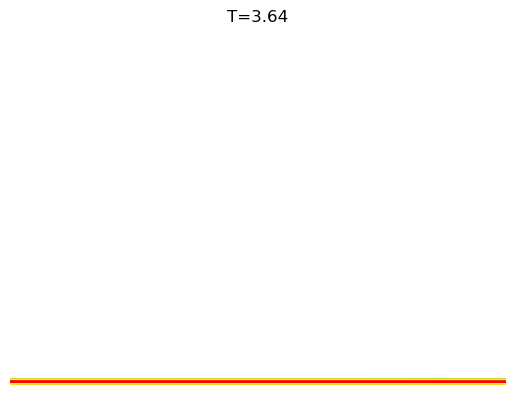

/tmp/ipykernel_3801141/1314693314.py:76: OptimizeWarning: Covariance of the parameters could not be estimated
  par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff]**1, susceptibiliteter2D[:, i][størrelser > sizeCutoff], sigma=susceptibiliteterUsik2D[:, i][størrelser > sizeCutoff], absolute_sigma=True)


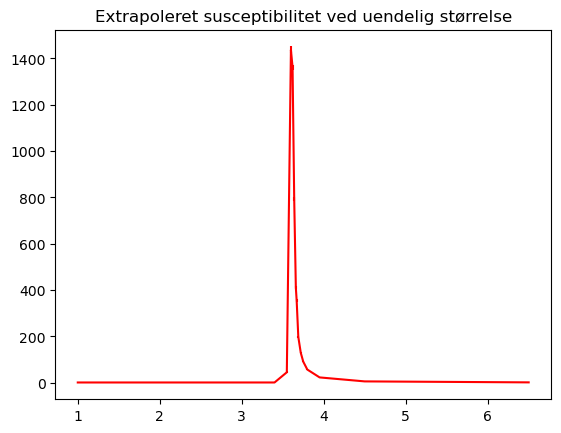

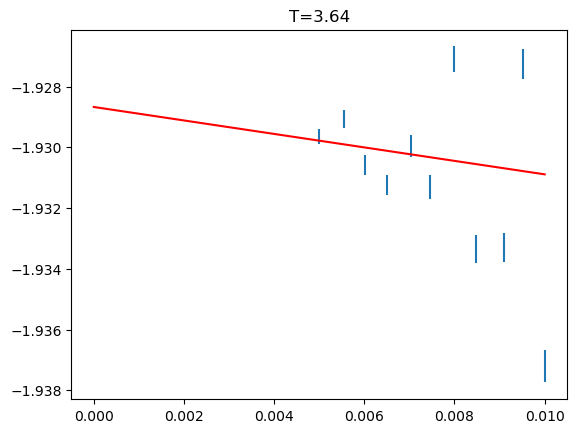

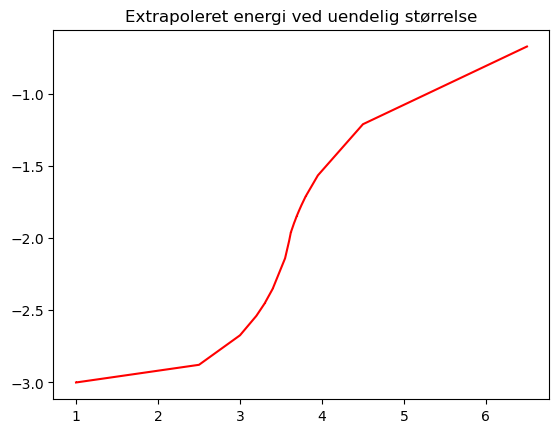

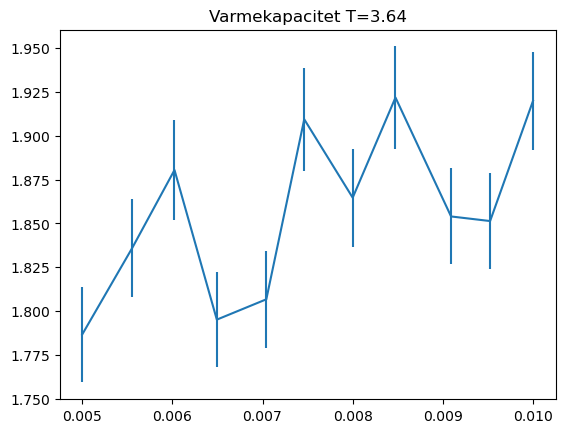

/tmp/ipykernel_3801141/1314693314.py:154: OptimizeWarning: Covariance of the parameters could not be estimated
  par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff]**1, varmekapaciteter2D[:, i][størrelser > sizeCutoff], sigma=varmekapaciteterUsik2D[:, i][størrelser > sizeCutoff]*1, absolute_sigma=True)


Reduced chi-squared for parabolic fit: 339.45
Kritisk temperatur fra parabolisk fit: 4.37774 ± 0.00547


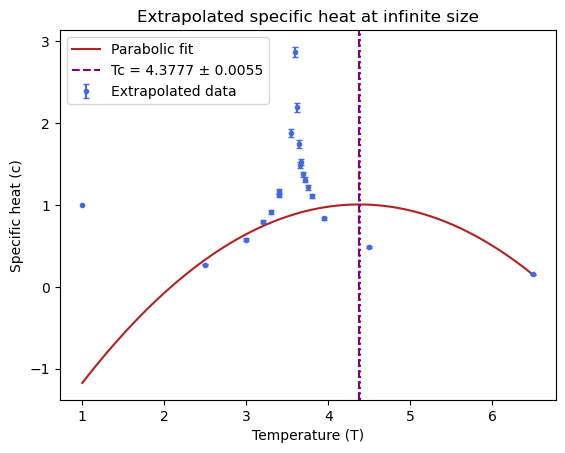

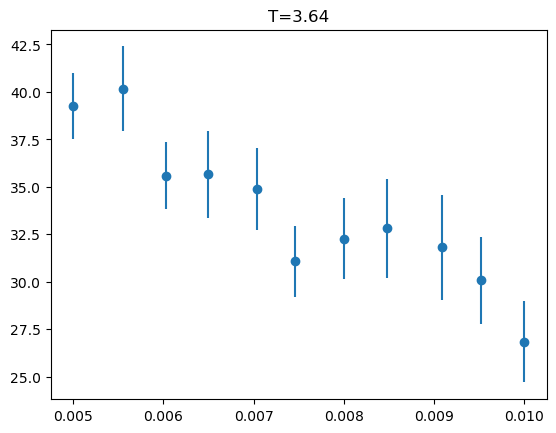

Extrapoleret kritisk temperatur: 3.62


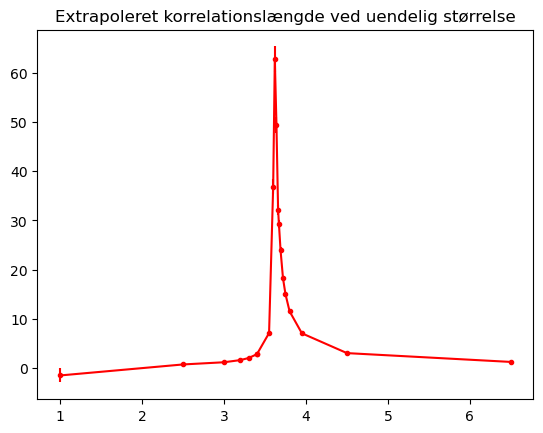

In [154]:


temptemp = 10
sizeCutoff = 101


plt.errorbar(temperaturer, korrLen2D[5], yerr=korrLenUsik2D[5], fmt=',', label=f"Data Size {størrelser[0]}")
plt.show()

for i in range(antalStørrelser):
    plt.plot(temperaturer, susceptibiliteter2D[i], label=f"Size {størrelser[i]}")
plt.legend()
plt.show()






# 1/size magnetisering extrapolation
plt.errorbar(1/størrelser, magnetiseringer2D[:, temptemp], yerr=magnetiseringerUsik2D[:, temptemp], fmt=',', label='Data', color='blue')
partemp, covtemp = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff], magnetiseringer2D[:, temptemp][størrelser > sizeCutoff], sigma=magnetiseringerUsik2D[:, temptemp][størrelser > sizeCutoff]*4.5, absolute_sigma=True)
x_fit_temp = np.linspace(0, 1/størrelser.min(), 100)
y_fit_temp = linfunc(x_fit_temp, *partemp)
plt.plot(x_fit_temp, y_fit_temp, label='Lineær fit', color='red')
plt.title(f'T={temperaturer[temptemp]}')
plt.show()


extrapoleretMagnetisering = np.zeros(antalTemperaturer)
extrapoleretMagnetiseringUsik = np.zeros(antalTemperaturer)

#fit af lineær funktion
for i in range(antalTemperaturer):
    par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff], magnetiseringer2D[:, i][størrelser > sizeCutoff], sigma = magnetiseringerUsik2D[:, i][størrelser > sizeCutoff], absolute_sigma=True)
    x_fit = np.linspace(0, 1/størrelser.min(), 100)
    y_fit = linfunc(x_fit, *par)

    extrapoleretMagnetisering[i] = par[1]
    extrapoleretMagnetiseringUsik[i] = cov[1, 1]**0.5

#OBS:: overvurderede usikkerheder så x4.5mangel af korrelation:

plt.plot(temperaturer, extrapoleretMagnetisering, label='Lineær fit', color='red')
plt.errorbar(temperaturer, extrapoleretMagnetisering, yerr=extrapoleretMagnetiseringUsik, fmt='o', label='Extrapoleret data', color='red')
plt.title('Extrapoleret magnetisering ved uendelig størrelse')

plt.show()


#Forside plot??


curve_colors = plt.cm.viridis(np.linspace(0, 1, antalStørrelser))
for i, c in enumerate(curve_colors):
    plt.plot(temperaturer, magnetiseringer2D[i], label=f"Size {størrelser[i]}", color=c, linewidth=4.5)

plt.plot(temperaturer, extrapoleretMagnetisering, label='Lineær fit', color='red', linewidth=2.0)
plt.xlim(1.5, 3.0)

#remove axes
plt.gca().set_axis_off()

plt.savefig("../plots/forside_plot.png", bbox_inches='tight', pad_inches=0, dpi=600)





plt.errorbar(1/(størrelser)**1, susceptibiliteter2D[:, temptemp], yerr=susceptibiliteterUsik2D[:, temptemp], fmt=',', label=f"Data Size {størrelser[0]}")
plt.title(f'T={temperaturer[temptemp]}')
plt.show()

extrapoleretSusceptibiliteter = np.zeros(antalTemperaturer)
extrapoleretSusceptibiliteterUsik = np.zeros(antalTemperaturer)
#fit af lineær funktion
for i in range(antalTemperaturer):
    par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff]**1, susceptibiliteter2D[:, i][størrelser > sizeCutoff], sigma=susceptibiliteterUsik2D[:, i][størrelser > sizeCutoff], absolute_sigma=True)
    x_fit = np.linspace(0, 1/størrelser.min(), 100)
    y_fit = linfunc(x_fit, *par)

    extrapoleretSusceptibiliteter[i] = par[1]
    extrapoleretSusceptibiliteterUsik[i] = cov[1, 1]**0.5


#plt.plot(temperaturer, extrapoleretSusceptibiliteter, label='Lineær fit', color='red')
plt.errorbar(temperaturer, extrapoleretSusceptibiliteter, yerr=extrapoleretSusceptibiliteterUsik, fmt='-', label='Extrapoleret data', color='red',)
plt.title('Extrapoleret susceptibilitet ved uendelig størrelse')
#plt.xlim(3,4)
#plt.xlim(2.2,2.4)
#plt.ylim(-0.01, 0.04)
'''
def parabola(x, x0, a, y0):
    return a*(x-x0)**2 + y0

par_sus, cov_sus = curve_fit(parabola, temperaturer, extrapoleretSusceptibiliteter, sigma=extrapoleretSusceptibiliteterUsik, absolute_sigma=True, maxfev=50000)   

x_par = np.linspace(temperaturer.min(), temperaturer.max(), 100)
y_par = parabola(x_par, *par_sus)
plt.plot(x_par, y_par, label='Parabolisk fit', color='green')

print(f"Kritisk temperatur fra parabolisk fit: {par_sus[0]:.5f} ± {cov_sus[0, 0]**0.5:.5f}")

chi2_red = np.sum(((extrapoleretSusceptibiliteter - parabola(temperaturer, *par_sus)) / extrapoleretSusceptibiliteterUsik) ** 2) / (len(temperaturer) - len(par_sus))
print(f"Reduced chi-squared for parabolic fit: {chi2_red:.2f}")
'''

plt.show()





plt.errorbar(1/størrelser, energier2D[:, temptemp], yerr=energierUsik2D[:, temptemp], fmt=',', label=f"Data Size {størrelser[0]}")
partemp, covtemp = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff], energier2D[:, temptemp][størrelser > sizeCutoff], sigma=energierUsik2D[:, temptemp][størrelser > sizeCutoff], absolute_sigma=True)
x_fit_temp = np.linspace(0, 1/størrelser.min(), 100)
y_fit_temp = linfunc(x_fit_temp, *partemp)
plt.plot(x_fit_temp, y_fit_temp, label='Lineær fit', color='red')


plt.title(f'T={temperaturer[temptemp]}')
plt.show()

extrapoleretEnergier = np.zeros(antalTemperaturer)
extrapoleretEnergierUsik = np.zeros(antalTemperaturer)

#fit af lineær funktion
for i in range(antalTemperaturer):
    par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff], energier2D[:, i][størrelser > sizeCutoff], sigma=energierUsik2D[:, i][størrelser > sizeCutoff], absolute_sigma=True)
    x_fit = np.linspace(0, 1/størrelser.min(), 100)
    y_fit = linfunc(x_fit, *par)

    extrapoleretEnergier[i] = par[1]
    extrapoleretEnergierUsik[i] = cov[1, 1]**0.5


plt.plot(temperaturer, extrapoleretEnergier, label='Lineær fit', color='red')
plt.errorbar(temperaturer, extrapoleretEnergier, yerr=extrapoleretEnergierUsik, fmt=',', label='Extrapoleret data', color='red')
plt.title('Extrapoleret energi ved uendelig størrelse')

plt.show()




plt.errorbar(1/(størrelser)**1, varmekapaciteter2D[:, temptemp], yerr=varmekapaciteterUsik2D[:, temptemp], fmt=',-', label=f"Data Size {størrelser[0]}")
plt.title(f'Varmekapacitet T={temperaturer[temptemp]}')
plt.show()

extrapoleretVarmekapaciteter = np.zeros(antalTemperaturer)
extrapoleretVarmekapaciteterUsik = np.zeros(antalTemperaturer)


#fit af lineær funktion
for i in range(antalTemperaturer):
    par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff]**1, varmekapaciteter2D[:, i][størrelser > sizeCutoff], sigma=varmekapaciteterUsik2D[:, i][størrelser > sizeCutoff]*1, absolute_sigma=True)
    x_fit = np.linspace(0, 1/størrelser.min(), 100)
    y_fit = linfunc(x_fit, *par)

    extrapoleretVarmekapaciteter[i] = par[1]
    extrapoleretVarmekapaciteterUsik[i] = cov[1, 1]**0.5

plt.errorbar(temperaturer, extrapoleretVarmekapaciteter, yerr=extrapoleretVarmekapaciteterUsik, fmt='.', label='Extrapolated data', color='royalblue', capsize=2)
plt.title('Extrapolated specific heat at infinite size')
plt.xlabel('Temperature (T)')
plt.ylabel('Specific heat (c)')


def parabola(x, x0, a, y0):
    return a*(x-x0)**2 + y0
par_sus, cov_sus = curve_fit(parabola, temperaturer, extrapoleretVarmekapaciteter, sigma=extrapoleretVarmekapaciteterUsik, absolute_sigma=True, maxfev=50000)
x_par = np.linspace(temperaturer.min(), temperaturer.max(), 100)
y_par = parabola(x_par, *par_sus)
plt.plot(x_par, y_par, label='Parabolic fit', color='firebrick')

chi2_red = np.sum(((extrapoleretVarmekapaciteter - parabola(temperaturer, *par_sus)) / extrapoleretVarmekapaciteterUsik) ** 2) / (len(temperaturer) - len(par_sus))
print(f"Reduced chi-squared for parabolic fit: {chi2_red:.2f}")

print(f"Kritisk temperatur fra parabolisk fit: {par_sus[0]:.5f} ± {cov_sus[0, 0]**0.5:.5f}")
Tc = par_sus[0]
Tc_usik = cov_sus[0, 0]**0.5

#plt.xlim(2.2,2.4)
#plt.xlim(3,4)
#plt.ylim(-2e-5, 1.8e-4)

plt.axvline(Tc, color='purple', linestyle='--', label=f'Tc = {Tc:.4f} ± {Tc_usik:.4f}')
plt.axvline(Tc + Tc_usik, color='purple', linestyle=':')
plt.axvline(Tc - Tc_usik, color='purple', linestyle=':')

plt.legend()
plt.show()


plt.errorbar(1/(størrelser)**1, korrLen2D[:, temptemp], yerr=korrLenUsik2D[:, temptemp]*2, fmt='o', label=f"Data Size {størrelser[0]}")
plt.title(f'T={temperaturer[temptemp]}')
plt.show()

extrapoleretKorrlen = np.zeros(antalTemperaturer)
extrapoleretKorrlenUsik = np.zeros(antalTemperaturer)

#fit af lineær funktion
for i in range(antalTemperaturer):
    par, cov = curve_fit(linfunc, 1/størrelser[størrelser > sizeCutoff]**1, korrLen2D[:, i][størrelser > sizeCutoff], sigma=korrLenUsik2D[:, i][størrelser > sizeCutoff], absolute_sigma=True)
    x_fit = np.linspace(0, 1/størrelser.min(), 100)
    y_fit = linfunc(x_fit, *par)

    extrapoleretKorrlen[i] = par[1]
    extrapoleretKorrlenUsik[i] = cov[1, 1]**0.5

Tc = temperaturer[np.argmax(extrapoleretKorrlen)]
print(f"Extrapoleret kritisk temperatur: {Tc}") 

plt.errorbar(temperaturer, extrapoleretKorrlen, yerr=extrapoleretKorrlenUsik, fmt='.-', label='Extrapoleret data', color='red')
plt.title('Extrapoleret korrelationslængde ved uendelig størrelse')

plt.show()


Temperaturer til fit: [1.   2.5  3.   3.2  3.3  3.4  3.4  3.55 3.6  3.62 3.64]
Reduced chi-squared for linear fit: 424.63


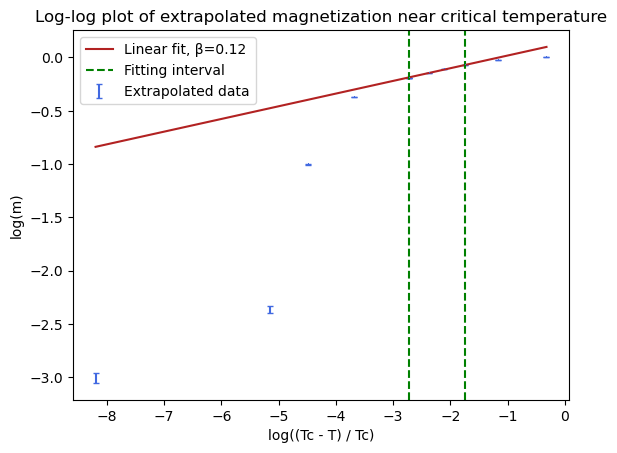

Kritisk eksponent for susceptibilitet: 0.11893 ± 0.00018
Reduced chi-squared for linear fit: 424.63


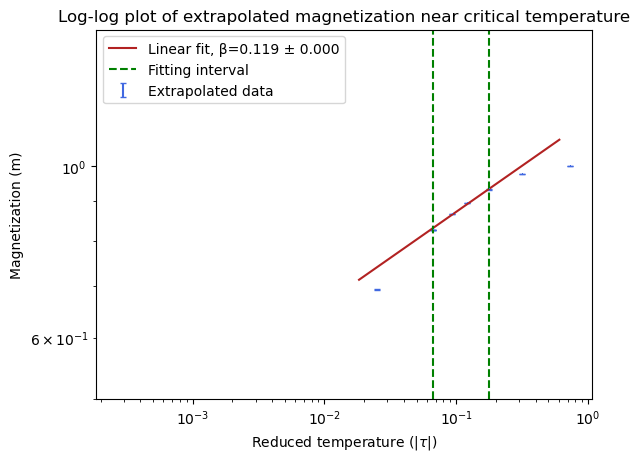

In [185]:
#find kritiske eksponenter ved at plotte log-log af magnetisering og temp

korrigeretMagnetiseringUsik = extrapoleretMagnetiseringUsik  # Overvurderede usikkerheder, så x2 for at få mere realistiske fejlstænger

#Tc = 2.2697
Tc = 3.641

startIndex = 0
endIndex = 11

fitStartIndex = 2
fitEndIndex = 7

print(f"Temperaturer til fit: {temperaturer[startIndex:endIndex]}")

plt.errorbar(np.log((Tc-temperaturer[startIndex:endIndex])/Tc), np.log(extrapoleretMagnetisering[startIndex:endIndex]), yerr=np.abs(korrigeretMagnetiseringUsik[startIndex:endIndex]/extrapoleretMagnetisering[startIndex:endIndex]), fmt=',', capsize=2, label='Extrapolated data', color='royalblue')
plt.xlabel(f'log((Tc - T) / Tc)')
plt.ylabel('log(m)')
plt.title('Log-log plot of extrapolated magnetization near critical temperature')

#fit af lineær funktion
par, cov = curve_fit(linfunc, np.log((Tc-temperaturer[fitStartIndex:fitEndIndex])/Tc), np.log(extrapoleretMagnetisering[fitStartIndex:fitEndIndex]), sigma=korrigeretMagnetiseringUsik[fitStartIndex:fitEndIndex]/extrapoleretMagnetisering[fitStartIndex:fitEndIndex], absolute_sigma=True)
x_fit = np.linspace(np.log((Tc-temperaturer[startIndex])/Tc), np.log((Tc-temperaturer[endIndex-1])/Tc), 100)
y_fit = linfunc(x_fit, *par)
plt.plot(x_fit, y_fit, label=f'Linear fit, β={par[0]:.2f}', color='firebrick')

#show fitting interval
plt.axvline(np.log((Tc-temperaturer[fitStartIndex])/Tc), color='green', linestyle='--', label='Fitting interval')
plt.axvline(np.log((Tc-temperaturer[fitEndIndex-1])/Tc), color='green', linestyle='--')

chi2_red = np.sum(((np.log(extrapoleretMagnetisering[fitStartIndex:fitEndIndex]) - linfunc(np.log((Tc-temperaturer[fitStartIndex:fitEndIndex])/Tc), *par)) / (korrigeretMagnetiseringUsik[fitStartIndex:fitEndIndex]/extrapoleretMagnetisering[fitStartIndex:fitEndIndex])) ** 2) / (len(temperaturer[fitStartIndex:fitEndIndex]) - len(par))
print(f"Reduced chi-squared for linear fit: {chi2_red:.2f}")

plt.legend()
plt.show()


print(f"Kritisk eksponent for susceptibilitet: {par[0]:.5f} ± {cov[0, 0]**0.5:.5f}")


# same plot, but with loglog axes:
plt.errorbar((Tc-temperaturer[startIndex:endIndex])/Tc, extrapoleretMagnetisering[startIndex:endIndex], yerr=korrigeretMagnetiseringUsik[startIndex:endIndex], fmt=',', capsize=2, label='Extrapolated data', color='royalblue')
plt.xscale('log')
plt.yscale('log')
#Latex labels
plt.xlabel(r'Reduced temperature ($|\tau|$)')
plt.ylabel('Magnetization (m)')
plt.title('Log-log plot of extrapolated magnetization near critical temperature')
#fit of linear function in log-log space
par, cov = curve_fit(linfunc, np.log((Tc-temperaturer[fitStartIndex:fitEndIndex])/Tc), np.log(extrapoleretMagnetisering[fitStartIndex:fitEndIndex]), sigma=np.abs(korrigeretMagnetiseringUsik[fitStartIndex:fitEndIndex]/extrapoleretMagnetisering[fitStartIndex:fitEndIndex]), absolute_sigma=True)
#x_fit = np.linspace(np.log((Tc-temperaturer[startIndex])/Tc), np.log((Tc-temperaturer[endIndex-1])/Tc), 100)
x_fit = np.linspace(-4, -0.5, 100)
y_fit = linfunc(x_fit, *par)
plt.plot(np.exp(x_fit), np.exp(y_fit), label=f'Linear fit, β={par[0]:.3f} ± {cov[0, 0]**0.5:.3f}', color='firebrick')
#show fitting interval
plt.axvline((Tc-temperaturer[fitStartIndex])/Tc, color='green', linestyle='--', label='Fitting interval')
plt.axvline((Tc-temperaturer[fitEndIndex-1])/Tc, color='green', linestyle='--')
chi2_red = np.sum(((np.log(extrapoleretMagnetisering[fitStartIndex:fitEndIndex]) - linfunc(np.log((Tc-temperaturer[fitStartIndex:fitEndIndex])/Tc), *par)) / (korrigeretMagnetiseringUsik[fitStartIndex:fitEndIndex]/extrapoleretMagnetisering[fitStartIndex:fitEndIndex])) ** 2) / (len(temperaturer[fitStartIndex:fitEndIndex]) - len(par))
print(f"Reduced chi-squared for linear fit: {chi2_red:.2f}")
plt.legend()
plt.ylim(0.5,1.5)
plt.show()

In [ ]:
heatmap_dir = "../output/Fourier" # HUSK AT ÆNDRE DEN HER TIL DEN RIGTIGE MAPPE !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
heatmapParameters = np.genfromtxt(heatmap_dir + "/parameters/parameters_64.csv", delimiter=",", skip_header=0)[:, :-1]
heatmapmeasurements = np.genfromtxt(heatmap_dir + "/measurements/measurements_64.csv", delimiter=",", skip_header=0)[:, :-1]

temperaturer = np.unique(heatmapParameters[:][1])
magnetfelter = np.unique(heatmapParameters[:][2])
magnetiseringer = np.zeros((len(temperaturer), len(magnetfelter)))
for i in range(len(temperaturer)):
    for j in range(len(magnetfelter)):
        magnetiseringer[i,j] = heatmapmeasurements[i*len(magnetfelter) + j, 1]


#lav et heatmap af magnetisering for alle magnetfelter og temperaturer

plt.figure(figsize=(16,16))
plt.imshow(magnetiseringer, extent=(magnetfelter.min(), magnetfelter.max(), temperaturer.min(), temperaturer.max()), aspect='auto', origin='lower', cmap=cm.viridis, norm=mcolors.Normalize(vmin=0, vmax=1))
plt.colorbar(label='Magnetisering')
plt.xlabel('Temperatur')
plt.ylabel('Størrelse')
plt.title('Magnetisering som funktion af temperatur og størrelse')
plt.show()

RuntimeError: No mappable was found to use for colorbar creation. First define a mappable such as an image (with imshow) or a contour set (with contourf).

<Figure size 1600x1600 with 0 Axes>